In [1]:
1+1


2

In [2]:
%pip install pandas numpy matplotlib scikit-learn 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import numpy as np # für Matrizen 
import matplotlib.pyplot as plt # Plotten / Graphik 

In [4]:
X = 2 * np.random.rand(100,1) # gleichmäßige Verteilung aus [0,2]
y = 4 + 3*X + np.random.randn(100,1) # lineare Funktion y = 3*x + 4 + eps; eps -> ist Rauschen/ normalverteilte Zufallszahlen

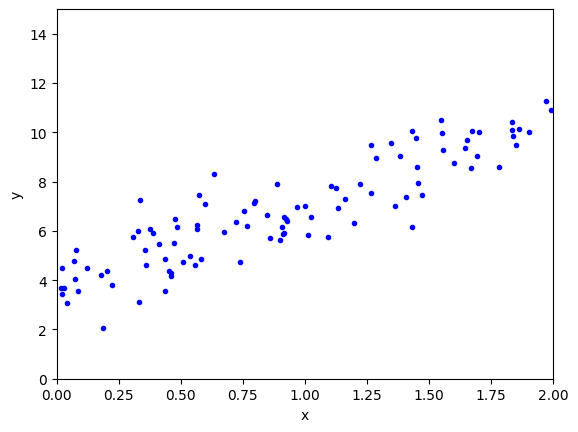

In [5]:
plt.plot(X, y,  "b.") # blaue Punkte 
plt.xlabel("x")
plt.ylabel("y")
plt.axis([0,2,0,15])
plt.show()

In [6]:
A = np.array([
    [1,2], 
    [3,4]
])
A @ A # Matrizenmultiplikation  7 = 1*1 + 2*3 

array([[ 7, 10],
       [15, 22]])

In [7]:
# y_pred = 3*x + 4 
# y_dach 
X_b = np.c_[X, np.ones((100,1))] # Feature-Engineering =  Merkmalskonstruktion 
w = np.array([[3], [4]]) 
y_pred = X_b @ w # Vorhersage 

In [8]:
from sklearn.preprocessing import add_dummy_feature

w = np.array([[4], [3]]) 
X_b = add_dummy_feature(X)
X_b

array([[1.        , 1.43149845],
       [1.        , 1.69396322],
       [1.        , 0.59759517],
       [1.        , 0.56577447],
       [1.        , 1.60139686],
       [1.        , 1.97065667],
       [1.        , 0.01559599],
       [1.        , 1.09380263],
       [1.        , 0.33489045],
       [1.        , 0.22370162],
       [1.        , 0.55786112],
       [1.        , 0.02108763],
       [1.        , 1.83451111],
       [1.        , 0.07149138],
       [1.        , 0.91562595],
       [1.        , 0.06995963],
       [1.        , 0.76749037],
       [1.        , 0.91448896],
       [1.        , 0.437143  ],
       [1.        , 1.55426728],
       [1.        , 0.63398714],
       [1.        , 1.43072221],
       [1.        , 1.78298667],
       [1.        , 0.48567177],
       [1.        , 1.28801446],
       [1.        , 0.11958312],
       [1.        , 0.92221205],
       [1.        , 0.30633404],
       [1.        , 0.46024817],
       [1.        , 0.41259034],
       [1.

$$
    \mathbf{w} = (\mathbf{X}^T\mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}
$$

In [9]:
w_best = np.linalg.inv(X_b.T @ X_b) @ X_b.T @ y
w_best

array([[3.71112694],
       [3.36620848]])

In [10]:
X_new = np.array([[0], [2]])
X_new_best = add_dummy_feature(X_new)
y_pred_best = X_new_best @ w_best

ValueError: x and y must have same first dimension, but have shapes (2, 1) and (100, 1)

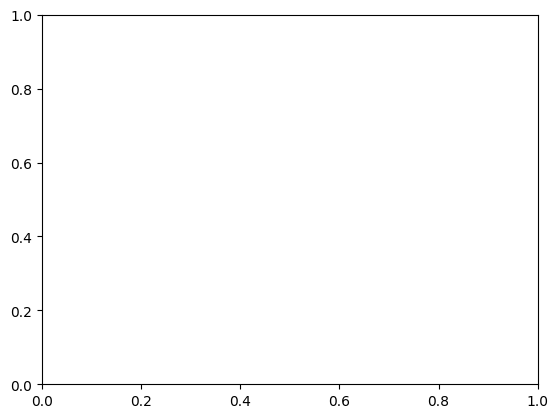

In [11]:
plt.figure() # Initialisierung
plt.plot(X_new, y_pred, "r-", label = "Vorhersage")
plt.plot(X,y, "b.")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [ ]:
from sklearn.linear_model import LinearRegression

lin_reg = LinearRegression()
lin_reg.fit(X,y) # X ... Eingänge, y ... gewünschte Ausgänge Modell wird trainiert 
lin_reg.coef_, lin_reg.intercept_ # Anstieg, Schnittpunkt mit y-Achse

(array([[2.88134602]]), array([4.18023678]))

In [ ]:
lin_reg.predict(X_new) # Modell anwenden 

array([[4.18023678],
       [9.94292882]])

# Gradient
$$
    MSE = \frac{1}{n}(\mathbf{X}\mathbf{w} - \mathbf{y})^T (\mathbf{X}\mathbf{w} - \mathbf{y})
$$
$$
    \frac{\partial MSE}{\partial w} = \frac{2}{n} \mathbf{X}^T (\mathbf{X} \mathbf{w} - y) 
$$



$$
    f = (2x + 3)^2 \\
    f' = 2  \cdot 2 \cdot(x+3)
$$


In [ ]:
# Batch gradient descent 

alpha = 0.1 # Lernrate 
n_epochs = 5 # 1 Epoche = 1 Mal hat ML Algorithmus den gesamten Datensatz "gesehen"

n = len(X_b) 
w = np.random.randn(2,1) # irgendwo zufällig 

for epoch in range(n_epochs): # Training-Loop 
    gradients = 2/n * X_b.T @ (X_b @ w - y) # Gradienten berechnen
    w = w - alpha * gradients

w


array([[3.43333921],
       [3.03998504]])

In [ ]:
# Stochastic gradient descent 

alpha = 0.001 # Lernrate 
n_epochs = 3 # 1 Epoche = 1 Mal hat ML Algorithmus den gesamten Datensatz "gesehen"

n = len(X_b) 
w = np.random.randn(2,1) # irgendwo zufällig 

for epoch in range(n_epochs): # Training-Loop 
    for iter in range(n): # iterieren über Datensatz
        r_indx = np.random.randint(n) # Zufälliger Index
        xi = X_b[r_indx:r_indx+1] # Auswahl vom Datenpunkt
        yi = y[r_indx:r_indx+1] 
        gradients = 2 * xi.T @ (xi @ w - yi) # Gradienten berechnen
        w = w - alpha * gradients

w

array([[2.82061405],
       [2.70447004]])

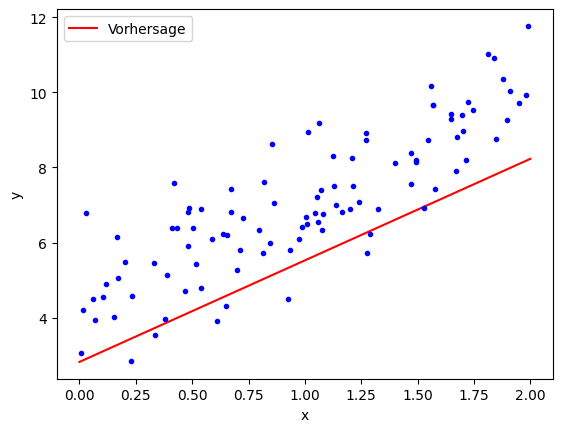

In [ ]:
# Mini-Batch stochastic gradient descent 

alpha = 0.01 # Lernrate 
n_epochs = 5 # 1 Epoche = 1 Mal hat ML Algorithmus den gesamten Datensatz "gesehen"
batch_size = 10 

n = len(X_b) 
w = np.random.randn(2,1) # irgendwo zufällig 

for epoch in range(n_epochs): # Training-Loop 
    shuffle_idx = np.random.permutation(n) # Mischen 
    X_b_shuffle = X_b[shuffle_idx]
    y_shuffle = y[shuffle_idx]
    for i in range(0, n, batch_size): # von Null bis N in batch_size Schritten 
        xi = X_b_shuffle[i:i+batch_size] # Auswahl vom Datenpunkten 
        yi = y_shuffle[i:i+batch_size]
        gradients = 2/batch_size * xi.T @ (xi @ w - yi) # Gradienten berechnen
        w = w - alpha * gradients
        
w

array([[2.05791962],
       [4.03162361]])

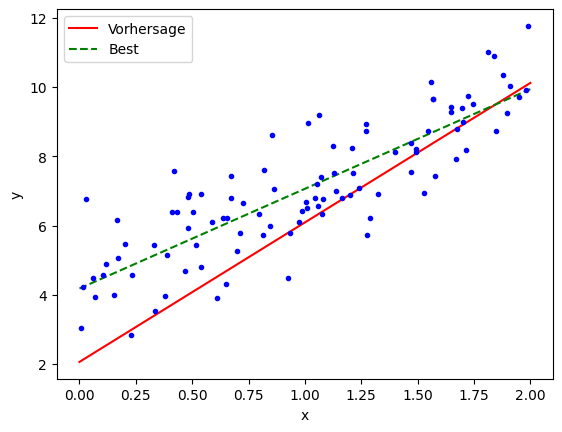

In [ ]:
X_new = np.array([[0], [2]])
X_new_b = add_dummy_feature(X_new)
y_pred = X_new_b @ w
plt.figure() # Initialisierung
plt.plot(X_new, y_pred, "r-", label = "Vorhersage")
plt.plot(X_new,y_pred_best,"g--", label = "Best")
plt.plot(X,y, "b.")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.show()

In [12]:
%pip install torch torchvision # für tiefe neuronale Netze

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip
ERROR: Invalid requirement: '#': Expected package name at the start of dependency specifier
    #
    ^


In [13]:
import torch 

x = torch.tensor([1,2,3]) # n-dimensionale Arrays 
x

tensor([1, 2, 3])

In [14]:
random_tensor = torch.rand(2,3) # zwei Zeilen, drei Spalten
random_tensor

tensor([[0.8021, 0.0351, 0.1074],
        [0.6708, 0.3070, 0.3398]])

In [15]:
x + random_tensor # Plus mit Broadcasting 

tensor([[1.8021, 2.0351, 3.1074],
        [1.6708, 2.3070, 3.3398]])

In [16]:
a = torch.tensor([[1.,2], [3,4]])
b = torch.tensor([[5.,6], [7,8]])

a @ b # oder torch.matmul(a,b)

tensor([[19., 22.],
        [43., 50.]])

In [17]:
a*b # elementenweise
a.sum() # Summe der Elemente
a.mean() # Durchschnitte

tensor(2.5000)

In [18]:
# devices 
device = torch.device("cpu")
# device = torch.device("cuda") # NVIDIA GPUs 
# device = torch.device("mps") # Apple Silicon 

In [19]:
# Gradienten (automatische Differentiation)

x = torch.tensor(2.0, requires_grad=True) # Modus: Schleppe alle Berechnungen mit 
y = x**2 + 3*x + 5 
# 2*x + 3 -> 2*2.0 + 3 = 7
y.backward() # Gradienten ausrechnen
x.grad

tensor(7.)

In [67]:
import torch.nn as nn 

# Modell
NN = nn.Linear(10, 1) # 10 Eingänge und 1 Ausgang w = (w_1, ..., w_10), model = w1*x1 + ... + w10*x10 + b 

# Verlustfunktion 
# MSE 
loss = nn.MSELoss() # loss, criterion
optimizer = torch.optim.SGD(NN.parameters(), lr=0.01) # stochastic gradient descent, lr ... Lernrate

input_data = torch.ones(10)*(-1) # hier Input 
out = NN(input_data) # das generiert Neuronales Netz, w1 ... w1 + b sind irgendwie zufällig initialisiert 
y = torch.tensor(1.) # wir wollen hierhin y = 1


loss_out = loss(out, y) # Unterschied zwischen Erwartung (out) & Realität (y) (quadratische Abweichung)
print("Anfangswert der Verlustfunktion:", loss_out) # Anfangswert der Verlustfunktion 

# zwei magische Zeilen 
loss_out.backward() # Gradienten berechnen
optimizer.step() # Update-Schritt 

out_new = NN(input_data) # bereits mit neuen Gewichten 
loss_new = loss(out_new, y) # Man hofft, dass dieser Wert kleiner ist, als Anfangswert 
print("Wert nach optimizer.step():", loss_new)

Anfangswert der Verlustfunktion: tensor(3.2617, grad_fn=<MseLossBackward0>)
Wert nach optimizer.step(): tensor(1.9844, grad_fn=<MseLossBackward0>)


In [68]:
out

tensor([-0.8060], grad_fn=<ViewBackward0>)

In [69]:
out_new

tensor([-0.4087], grad_fn=<ViewBackward0>)

In [71]:
y

tensor(1.)

In [75]:
from torch.utils.data import DataLoader, TensorDataset

X = 2 * np.random.rand(100,1) # gleichmäßige Verteilung aus [0,2]
y = 4 + 3*X + np.random.randn(100,1) # lineare Funktion y = 3*x + 4 + eps; eps -> ist Rauschen/ normalverteilte Zufallszahlen

X_torch = torch.tensor(X, dtype=torch.float32)
y_torch = torch.tensor(y, dtype=torch.float32)

dataset = TensorDataset(X_torch, y_torch)
loader = DataLoader(dataset, batch_size=8, shuffle=True) # stochastic mini batch 

# y = w1*x1 + b 
model = nn.Linear(1,1) # Ein Eingang + b, Ein Ausgang 
loss_fn = nn.MSELoss() 
optimizer = torch.optim.SGD(model.parameters(), lr = 0.1)

n_epochs = 200

for epoch in range(n_epochs): 
    for xb,yb in loader:
        y_pred = model(xb) # Vorhersage
        loss = loss_fn(y_pred, yb) 

        optimizer.zero_grad() # Gradient auf Null setzen 
        loss.backward() # Gradient berechnen
        optimizer.step() # Verfahren anwenden 


# Resultate 
model.weight.detach().numpy(), model.bias.detach().numpy()


(array([[2.9231575]], dtype=float32), array([4.044981], dtype=float32))